## Portfolio - Predicción de goles en partidos FIFA WC26

### Limpieza de datos,  Modelación y Predicción de goles

En este paso se realizan los siguientes pasos:

1. Conexión API a los partidos FIFA WC26
2. Limpieza y transformación de columnas
3. Creación de variables para el modelo
3. Modelación
4. Predicción Partidos

Paso 1 - Librerias a importar

- Pandas
- numpy
- requests
- utils2.py (archivo con funciones de limpieza y captura de datos)

In [1]:
import pandas as pd
from datetime import datetime
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf

import utils2 as utils

Paso 2 - Obtener datos FIFA WC26 por API (partidos, games y estadios)

[Revisar repo - Github FIFA WC26 API](https://github.com/rezarahiminia/worldcup2026)

In [2]:
# 1. Obtener los próximos partidos (vía API o descarga directa)
url_g = "https://worldcup26.ir/get/games"
url_t = "https://worldcup26.ir/get/teams"
url_s = "https://worldcup26.ir/get/stadiums"

response = requests.get(url_g)
calendario = response.json()
response = requests.get(url_t)
teams = response.json()
response = requests.get(url_s)
stadiums = response.json()

#Paises y Estadios
dict_estadios = utils.crear_diccionario_estadios(stadiums)
id_to_fifa = {team['id']: team['fifa_code'] for team in teams['teams']}
name_to_fifa = {team['id']: team['name_en'] for team in teams['teams']}

Estandarizar BBDD FIFA WC26

In [25]:
df_wc = utils.preparar_calendario(calendario['games'])
df_wc = df_wc[df_wc['Team_id'] != "0"].copy() #Descarta partidos sin asignación de equipos
df_wc['Team'] = df_wc['Team_id'].map(id_to_fifa)
df_wc['Date'] = pd.to_datetime(df_wc['Date']).dt.strftime("%Y-%m-%d")
df_wc['Game_type'] = 'FIFA WC26'
df_wc['Venue'] = df_wc['stadium_id'].map(dict_estadios)
df_wc['Condition'] = np.where(df_wc['Team'].isin(['CAN','MEX','USA']), 'L', 'N')
df_wc['Opponent'] = df_wc['Opponent_id'].map(name_to_fifa)
df_wc['Goals_team'] = pd.to_numeric(df_wc['home_score'], errors='coerce')
df_wc['Goals_opponent'] = pd.to_numeric(df_wc['away_score'], errors='coerce')
df_wc['Penalties'] = np.where(df_wc['Game_id'].isin(['74','75','82','86','88']), True, False)
df_wc['AET'] = np.where(df_wc['Game_id'].isin(['74','75','88']), True, False)
df_wc = df_wc[['Team', 'Date', 'Game_type', 'Venue', 'Condition', 'Opponent', 
        'Goals_team', 'Goals_opponent', 'Penalties', 'AET', 'Game_id']].copy()


Penalties & AET

Juntar BBDD para transformación y limpieza

In [26]:
df_games = pd.read_parquet('../database/games.parquet').drop(columns=['Resultado_Original'])
df_games = df_games[pd.to_datetime(df_games['Date']).dt.date < pd.Timestamp('2026-06-11').date()].copy()
df_games = pd.concat([df_games, df_wc])

Paso 3 - Limpieza y transformacion de variables

In [27]:
# Codigo FIFA Oponente
country_dict = pd.read_parquet('../database/ranking_fifa.parquet').set_index('Seleccion')['Codigo_Pais'].to_dict()
mapa_final = country_dict | utils.mapa_nombres

df_games['Opponent2'] = df_games['Opponent'].map(mapa_final)
df_games = df_games[df_games['Opponent2'].notna()].copy()

df_games['Goals_team'].fillna(0, inplace=True)
df_games['Goals_opponent'].fillna(0, inplace=True)

# Torneos
df_games['Game_type'] = df_games['Game_type'].apply(utils.reclass_torneos)
print(df_games['Game_type'].value_counts())

Game_type
Friendly          579
Federation Cup    567
WC Qualifiers     517
Nations League    211
World Cup         192
Other             136
Name: count, dtype: int64


Filtro selecciones que quedan

In [28]:
teams_r32 = ['ALG', 'ARG', 'AUS', 'AUT', 'BEL', 'BIH', 'BRA', 'CAN', 'CIV', 'COD', 'COL', 'CPV', 'CRO', 'ECU', 'EGY', 'ENG', 'ESP', 'FRA', 'GER', 'GHA', 'JPN', 'MAR', 'MEX', 'NED', 'NOR', 'PAR', 'POR', 'RSA', 'SEN', 'SUI', 'SWE', 'USA']
teams_r16 = ['ARG', 'BEL', 'BRA', 'CAN', 'COL', 'EGY', 'ENG', 'ESP', 'FRA', 'MAR', 'MEX', 'NOR', 'PAR', 'POR', 'SUI', 'USA']
df_games = df_games[df_games['Team'].isin(teams_r32)].copy()
print(df_games['Game_type'].value_counts())

Game_type
Federation Cup    414
Friendly          391
WC Qualifiers     309
World Cup         144
Nations League    142
Other              76
Name: count, dtype: int64


4 - Creación variables al modelo

Las variables a utilizar son las siguientes:

**Fecha**: Se utilizará un decaimiento exponencial a la diferencia en días entre el 20/Jul/26 (Día posterior a la final FIFA WC26) y el día del partido.

**Es_Local**: Variable binaria si el equipo está en condición de local.

**AET_LastGame**: Variable binaria que indica si el partido anterior hubo alarge (Added Extra Time - AET).

**Game_type**: Tipo de competicion (Amistoso, Clasificatoria, Copa de Federaciones (Euro, America, Asia, ...))

**goals_team_avg**: N goles convertidos por el equipo en los últimos 5 partidos.

**goals_avg**: N goles convertidos en los últimos 5 partidos

In [29]:
df_games.shape

(1476, 12)

In [30]:
last_games = 4
df_games = utils.calcular_decaimiento_exponencial(df_games, alpha=0.01)
df_games['Es_Local'] = (df_games['Condition'] == 'L').astype(int)
df_games = utils.crear_ventana_fatiga(df_games)
df_games = utils.calcular_estadisticas_moviles(df_games, ventana=last_games)
df_games['Weight'] = df_games['Game_type'].apply(utils.asignar_peso)
#df_games = df_games.dropna()
print(df_games.shape)


(1476, 18)


**z-score_rank**: Diferencia estandarizada en el ranking FIFA entre la selección y su equipo Oponente. En vez de usar el nmro de ranking, se usan los puntos FIFA. 

Para ello se usa el último ranking FIFA, se calcula la diferencia en puntos entre la selección y su oponente. Al ser una variable numérica, se estandariza en media y varianza.

Adicionalmente, para descartar datos anómalos, se descartan partidos con más de 10 goles y partidos con diferencia en puntos FIFA muy alto (Diferencia en ptos FIFA entre -650 y 650 ptos).

In [31]:
scaler = StandardScaler()
df_ranking = pd.read_parquet('../database/ranking_fifa.parquet')
ranking_dict = dict(zip(df_ranking['Codigo_Pais'], df_ranking['Puntos_FIFA']))

df_games['Ranking_Team'] = df_games['Team'].map(ranking_dict)
df_games['Ranking_Opponent'] = df_games['Opponent2'].map(ranking_dict)
df_games['Ranking_diff'] = df_games['Ranking_Team'] - df_games['Ranking_Opponent']

df_games = df_games[df_games['Goals_team'] < 9].copy() #Descartar partidos con más de 10 goles

df_games = df_games[(df_games['Ranking_diff'] < 650)&(df_games['Ranking_diff'] > -650)].copy() #Descartar partidos con más de 10 goles
df_games['Zscore_Rank'] = scaler.fit_transform(df_games[['Ranking_diff']])
print(df_games.shape)


(1414, 22)


Separar datos de predicción con los de entrenamiento

Los datos de predicción son los partidos que aún no se realizan

In [32]:
date_filter = df_games['Date'].dt.normalize() < (pd.Timestamp.now()).normalize()

df_train = df_games[date_filter].copy()
df_test = df_games[~date_filter].copy()

In [33]:
df_train[df_train['Game_type']=='World Cup'].sort_values(by='Date')

,Team,Date,Game_type,Venue,Condition,Opponent,Goals_team,Goals_opponent,Penalties,AET,...,Date_decay,Es_Local,AET_LastGame,goals_team_avg,goals_avg,Weight,Ranking_Team,Ranking_Opponent,Ranking_diff,Zscore_Rank
1,RSA,2026-06-11,World Cup,"Estadio Azteca, Mexico City, Mexico",N,Mexico,0.0,2.0,False,False,...,0.677057,0,0,0.75,1.75,0.8,1418.211807,1721.782405,-303.570598,-2.109284
0,MEX,2026-06-11,World Cup,"Estadio Azteca, Mexico City, Mexico",L,South Africa,2.0,0.0,False,False,...,0.677057,1,0,2.25,2.75,0.8,1721.782405,1418.211807,303.570598,0.558667
4,CAN,2026-06-12,World Cup,"BMO Field, Toronto, Canada",L,Bosnia and Herzegovina,1.0,1.0,False,False,...,0.683861,1,0,1.25,2.00,0.8,1572.133422,1381.176640,190.956782,0.063810
6,USA,2026-06-12,World Cup,"SoFi Stadium, Los Angeles (Inglewood), United ...",L,Paraguay,4.0,1.0,False,False,...,0.683861,1,0,1.50,4.25,0.8,1709.589988,1488.048969,221.541019,0.198206
7,PAR,2026-06-12,World Cup,"SoFi Stadium, Los Angeles (Inglewood), United ...",N,United States,1.0,4.0,False,False,...,0.683861,0,0,2.00,2.75,0.8,1488.048969,1709.589988,-221.541019,-1.748823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,EGY,2026-07-03,World Cup,"AT&T Stadium, Dallas (Arlington, Texas), Unite...",N,Australia,1.0,1.0,True,True,...,0.843665,0,0,1.50,2.75,0.8,1570.668614,1584.552251,-13.883637,-0.836317
171,CPV,2026-07-03,World Cup,"Hard Rock Stadium, Miami (Miami Gardens), Unit...",N,Argentina,2.0,3.0,True,False,...,0.843665,0,0,1.25,1.75,0.8,1389.785087,1889.062265,-499.277178,-2.969274
172,COL,2026-07-03,World Cup,"GEHA Field at Arrowhead Stadium, Kansas City, ...",N,Ghana,1.0,0.0,False,False,...,0.843665,0,0,1.50,1.75,0.8,1712.604162,1380.707809,331.896353,0.683139
174,AUS,2026-07-03,World Cup,"AT&T Stadium, Dallas (Arlington, Texas), Unite...",N,Egypt,1.0,1.0,True,True,...,0.843665,0,0,1.75,2.50,0.8,1584.552251,1570.668614,13.883637,-0.714300


In [34]:
df_test

,Team,Date,Game_type,Venue,Condition,Opponent,Goals_team,Goals_opponent,Penalties,AET,...,Date_decay,Es_Local,AET_LastGame,goals_team_avg,goals_avg,Weight,Ranking_Team,Ranking_Opponent,Ranking_diff,Zscore_Rank
188,ARG,2026-07-07,World Cup,"Mercedes-Benz Stadium, Atlanta, United States",N,Egypt,0.0,0.0,False,False,...,0.878095,0,0,2.75,3.50,0.8,1889.062265,1570.668614,318.393651,0.623804
187,BEL,2026-07-06,World Cup,"Lumen Field, Seattle, United States",N,United States,0.0,0.0,False,False,...,0.869358,0,0,2.25,3.25,0.8,1733.934577,1709.589988,24.344589,-0.668331
180,BRA,2026-07-05,World Cup,"MetLife Stadium, New York/New Jersey (East Rut...",N,Norway,0.0,0.0,False,False,...,0.860708,0,0,2.25,2.75,0.8,1765.340396,1577.184771,188.155625,0.051501
178,CAN,2026-07-04,World Cup,"NRG Stadium, Houston, United States",L,Morocco,0.0,0.0,False,False,...,0.852144,1,0,2.25,3.00,0.8,1572.133422,1755.616133,-183.482711,-1.581584
191,COL,2026-07-07,World Cup,"BC Place, Vancouver, Canada",N,Switzerland,0.0,0.0,False,False,...,0.878095,0,0,1.25,1.50,0.8,1712.604162,1654.939343,57.664819,-0.521913
189,EGY,2026-07-07,World Cup,"Mercedes-Benz Stadium, Atlanta, United States",N,Argentina,0.0,0.0,False,False,...,0.878095,0,1,1.50,2.50,0.8,1570.668614,1889.062265,-318.393651,-2.174421
183,ENG,2026-07-05,World Cup,"Estadio Azteca, Mexico City, Mexico",N,Mexico,0.0,0.0,False,False,...,0.860708,0,0,2.00,2.75,0.8,1847.677458,1721.782405,125.895053,-0.222090
185,ESP,2026-07-06,World Cup,"AT&T Stadium, Dallas (Arlington, Texas), Unite...",N,Portugal,0.0,0.0,False,False,...,0.869358,0,0,2.00,2.00,0.8,1856.033671,1755.093610,100.940061,-0.331749
177,FRA,2026-07-04,World Cup,"Lincoln Financial Field, Philadelphia, United ...",N,Paraguay,0.0,0.0,False,False,...,0.852144,0,0,3.25,3.75,0.8,1887.107625,1488.048969,399.058656,0.978269
179,MAR,2026-07-04,World Cup,"NRG Stadium, Houston, United States",N,Canada,0.0,0.0,False,False,...,0.852144,0,1,1.75,2.75,0.8,1755.616133,1572.133422,183.482711,0.030967


Paso 4 - Modelación

Antes de aplicar GLM Poission, revisamos descriptivamente los datos

Variable respuesta

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


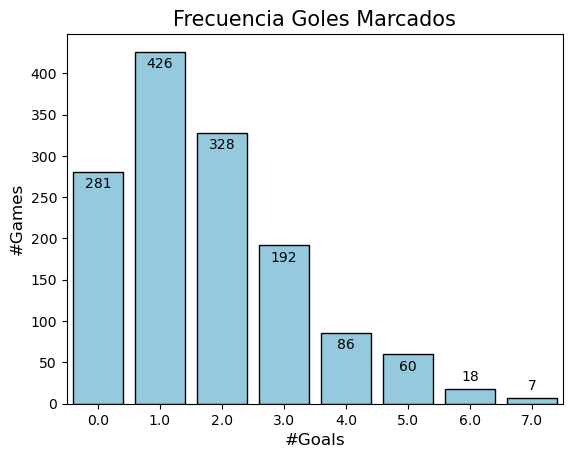

In [35]:
# Usamos countplot en lugar de histplot para datos discretos
# Esto asegura que cada columna esté alineada exactamente con el número de goles
ax = sns.countplot(data=df_train, x='Goals_team', color='skyblue', edgecolor='black')

# Añadir etiquetas de cantidad sobre cada barra para mayor claridad
for p in ax.patches:
    if p.get_x() < 5 :
        ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, -9), 
                textcoords='offset points')
    else :
        ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')
    
plt.title('Frecuencia Goles Marcados', fontsize=15)
plt.xlabel('#Goals', fontsize=12)
plt.ylabel('#Games', fontsize=12)
plt.savefig('../imgs/goals.png')

Validación gráfica otras variables

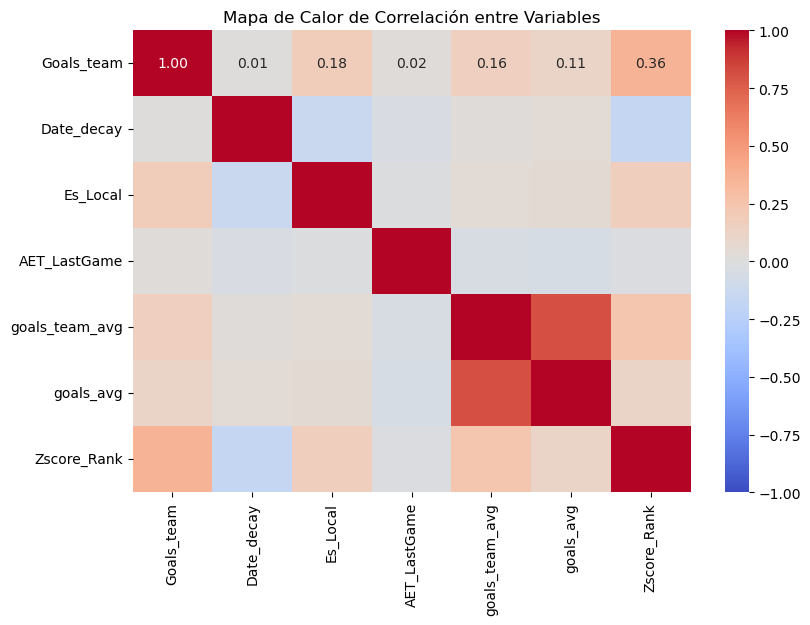

In [36]:
vars = ['Goals_team', 'Date_decay', 'Es_Local', 'AET_LastGame', 'goals_team_avg', 'goals_avg', 'Zscore_Rank']
# Calculamos la matriz de correlación
correlacion = df_train[vars].corr()

# Creamos el mapa de calor
plt.figure(figsize=(9, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Mapa de Calor de Correlación entre Variables')
plt.savefig('../imgs/corr.png')

Modelación / Cantidad de goles ~ Modelo GLM Poisson

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 1398
Model:                            GLM   Df Residuals:                     1386
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2234.9
Date:               sáb, 04 jul. 2026   Deviance:                       1604.0
Time:                        10:47:03   Pearson chi2:                 1.41e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1879
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

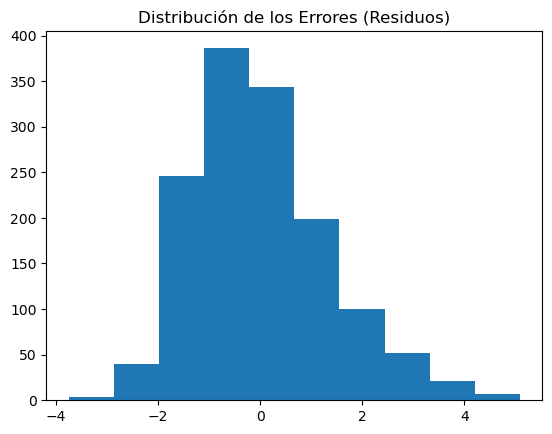

In [37]:
formula = "Goals_team ~ Date_decay + C(Game_type) + Zscore_Rank + Es_Local + goals_team_avg + goals_avg + AET_LastGame"

# Ajuste del modelo
model_1 = smf.glm(formula=formula, data=df_train, family=sm.families.Poisson()).fit()
                #var_weights=df_final['Peso_Partido']).fit()

df_model_1 = df_train.copy()
df_model_1['Prediccion'] = model_1.predict(df_model_1)
df_model_1['Error'] = df_model_1['Goals_team'] - df_model_1['Prediccion']

print(model_1.summary())
print("******* AIC:",model_1.aic,"*******")
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_1['Error'], bins=10)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Modelo sin variables Redundantes

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 1398
Model:                            GLM   Df Residuals:                     1393
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2259.4
Date:               sáb, 04 jul. 2026   Deviance:                       1652.9
Time:                        10:47:16   Pearson chi2:                 1.46e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1590
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.3403      0.062      5.

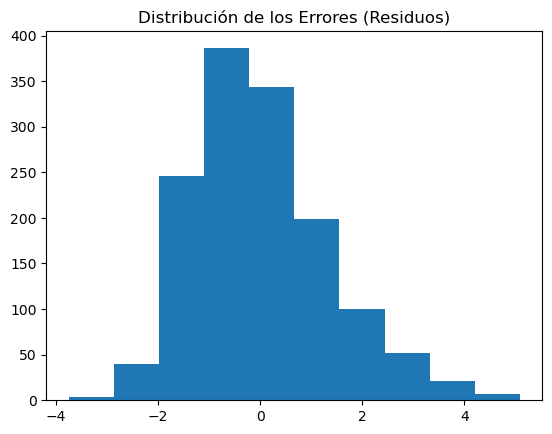

In [38]:
formula = "Goals_team ~ Zscore_Rank + goals_team_avg + AET_LastGame + goals_avg"
# Ajuste del modelo
model_2 = smf.glm(formula=formula, data=df_train, family=sm.families.Poisson()).fit()
                #var_weights=df_final['Peso_Partido']).fit()

df_model_2 = df_train.copy()
df_model_2['Prediccion'] = model_1.predict(df_model_2)
df_model_2['Error'] = df_model_2['Goals_team'] - df_model_2['Prediccion']

print(model_2.summary())
print("******* AIC:",model_2.aic,"*******")
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_2['Error'], bins=10)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Modelo con ponderador según torneo

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 1398
Model:                            GLM   Df Residuals:                     1392
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1219.0
Date:               sáb, 04 jul. 2026   Deviance:                       881.47
Time:                        10:47:24   Pearson chi2:                     780.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.09834
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.3068      0.086      3.

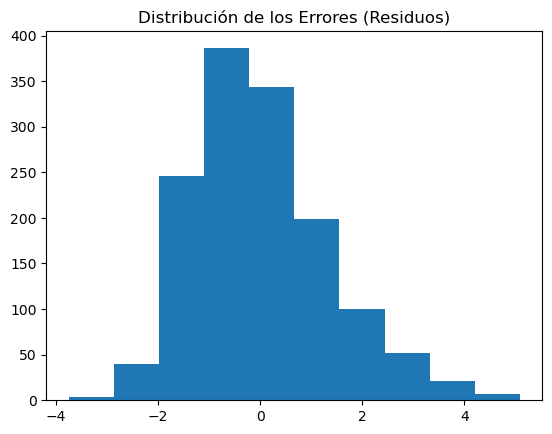

In [39]:
formula = "Goals_team ~ Date_decay + Zscore_Rank + goals_team_avg + AET_LastGame + goals_avg"
#"Goals_team ~ Date_decay + Zscore_Rank + goals_team_avg"

# Ajuste del modelo
model_3 = smf.glm(formula=formula, data=df_train, family=sm.families.Poisson(),
                var_weights=df_train['Weight']).fit()

df_model_3 = df_train.copy()
df_model_3['Prediccion'] = model_1.predict(df_model_2)
df_model_3['Error'] = df_model_3['Goals_team'] - df_model_3['Prediccion']

print(model_3.summary())
print("******* AIC:",model_3.aic,"*******")
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_3['Error'], bins=10)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Comparacion entre modelos

Para ello usamos el críterio de Akaike

In [40]:
print(f"M1: {model_1.aic}")
print(f"M2: {model_2.aic}")
print(f"M3: {model_3.aic}")

M1: 4493.867037646594
M2: 4528.787559267674
M3: 2449.9087287027914


El modelo es aquel con menos críterio de Akaike, es decir, el modelo con ponderador por tipo de Torneo

In [41]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(df_model_3['Goals_team'], df_model_3['Prediccion'])
print(f"Error promedio: {mae:.2f} goles por partido")

Error promedio: 1.05 goles por partido


In [42]:
# Identificar partidos donde el error es mayor a 2 goles
df_model_3['Abs_Error'] = abs(df_model_3['Error'])
fallos_graves = df_model_3.sort_values(by='Abs_Error', ascending=False).head(10)
print(fallos_graves[['Date', 'Team', 'Opponent', 'Goals_team', 'Prediccion','Ranking_diff']])

           Date Team                Opponent  Goals_team  Prediccion  \
820  2026-03-27  ALG               Guatemala         7.0    1.911959   
1941 2025-06-17  CAN                Honduras         6.0    1.382472   
1705 2023-09-08  ESP                 Georgia         7.0    2.484953   
76   2025-09-09  COL               Venezuela         6.0    1.508432   
1368 2024-03-26  AUT                  Turkey         6.0    1.576438   
505  2024-09-05  JPN                   China         7.0    2.668935   
1508 2023-06-19  ENG         North Macedonia         7.0    2.723035   
1733 2025-09-07  ESP                  Turkey         6.0    1.808379   
1611 2024-11-16  GER  Bosnia and Herzegovina         7.0    2.909266   
1632 2023-09-07  NOR                  Jordan         6.0    1.970500   

      Ranking_diff  
820     320.493849  
1941    193.163121  
1705    500.771984  
76      243.426490  
1368     33.389825  
505     411.134896  
1508    478.518141  
1733    276.567529  
1611    362.368295

Gráfico de Ranking_diff

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


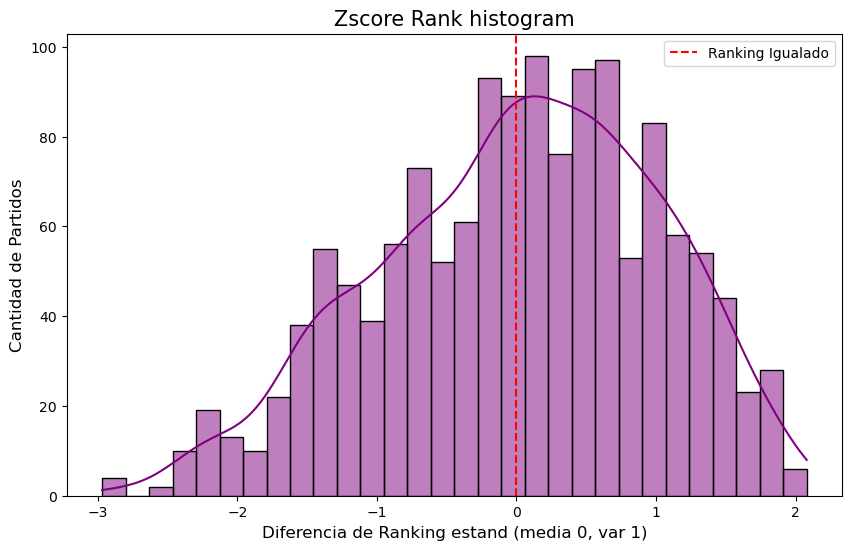

In [43]:
plt.figure(figsize=(10, 6))

# Histograma con KDE para ver la distribución
sns.histplot(df_train['Zscore_Rank'], kde=True, bins=30, color='purple', edgecolor='black')

# Línea vertical en 0 (Equipos de igual ranking)
plt.axvline(0, color='red', linestyle='--', label='Ranking Igualado')

plt.title('Zscore Rank histogram', fontsize=15)
plt.xlabel('Diferencia de Ranking estand (media 0, var 1)', fontsize=12)
plt.ylabel('Cantidad de Partidos', fontsize=12)
plt.legend()
plt.savefig('../imgs/Zscore_dist.png')

Predicción próximos partidos

In [44]:
df_goals_upd = df_train.sort_values(['Team', 'Date']).groupby('Team').tail(last_games)
df_goals_upd['total_goals'] = df_goals_upd['Goals_team'] + df_goals_upd['Goals_opponent']
metricas_recientes = df_goals_upd.groupby('Team').agg({'Goals_team': 'mean','total_goals': 'mean'}).rename(
    columns={'total_goals':'goals_avg', 'Goals_team':'goals_team_avg'})
metricas_recientes.sample(3)

df_test = df_test.drop(columns = ['goals_team_avg', 'goals_avg']).merge(metricas_recientes, on='Team', how='left')

In [45]:
df_test['Model_predict'] = model_3.predict(df_test)
df_test['Goles_Estimados'] = np.where(df_test['Model_predict']<1.3, df_test['Model_predict'].astype(int), df_test['Model_predict'].round(0).astype(int))

In [46]:
filtro = df_test['Date'].dt.date == pd.Timestamp('2026-07-04').date()
df_hoy = df_test[filtro]
print(df_hoy[['Team', 'Opponent', 'Goles_Estimados','Model_predict']])

   Team  Opponent  Goles_Estimados  Model_predict
3   CAN   Morocco                1       1.194530
8   FRA  Paraguay                3       2.946307
9   MAR    Canada                2       2.386029
12  PAR    France                0       0.967374


Guardar pronóstico

In [47]:
df_test.to_parquet('../database/predictions_r16.parquet')